## Abstract

The purpose of this report was to develop a binary classification model to predict notable wildfires given data from the previous month. Using a 100,000 observation sample of the US Wildfire dataset, we construct a grid-by-month panel spanning 1992 to 2015, with each observation being represented by a 1 degree x 1 degree square, and the outcome indicating if at least one fire exceeding 300 acres occurs in the following month. Through EDA, we discover that the West Coast is more prone to notable wildfires, and that there is a clear period of time (May, June, and July) where notable wildfires are more common. We compare a logistic regression and XGBoost model; logistic regression for its interpretability for binary classification problems, and XGBoost for its high performance with structured datasets. Overall, based on AUC, the XGBoost model outperforms the logistic regression model by 12.8%.

In [2]:
suppressMessages({
    library(dplyr)
    library(ggplot2)
    library(tidyverse)
    library(slider)
    library(pROC)
    library(xgboost)
    library(Matrix)
    library(tidyverse)
    library(nnet)
})

## 1. Data Preprocessing
This section explains how the raw wildfire incident table is converted into a grid-by-month dataset suitable for prediction.

We cover:
- How **notable** fires are identified and filtered
- How **space–time units** are constructed (grid × month)
- How the **binary outcome** is defined
- How **predictors** are constructed (lagged to avoid leakage)
- How missing data / edge cases are handled

### Goal
Create a *modeling-ready* dataset with one row per **(grid cell, month)** and a binary outcome:

> **Outcome** $Y_{g,t}$: whether at least one *notable* fire occurs in **grid cell $g$** in **month $t+1$**.

This “next month” target avoids same-month leakage and matches the project objective of near-future prediction.

### Load Data

Key variable definitions (USDA Forest Service metadata):
- `FIRE_YEAR`: Calendar year the fire was discovered
- `DISCOVERY_DOY`: Day-of-year the fire was discovered
- `FIRE_SIZE`: Final fire size (acres)
- `LATITUDE`, `LONGITUDE`: Ignition location (decimal degrees)
- `STATE`: State in which the fire burned

In [2]:
wildfires <- read_csv("wildfires_sample_100k.csv") %>% 
  select(FIRE_YEAR, DISCOVERY_DOY, FIRE_SIZE, LATITUDE, LONGITUDE, STATE) %>%
  mutate(STATE = as.factor(STATE)) %>% arrange(FIRE_YEAR, DISCOVERY_DOY, LATITUDE, LONGITUDE)

glimpse(wildfires)

Rows: 100000 Columns: 39
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (27): FPA_ID, SOURCE_SYSTEM_TYPE, SOURCE_SYSTEM, NWCG_REPORTING_AGENCY, ...
dbl (12): OBJECTID, FOD_ID, FIRE_YEAR, DISCOVERY_DATE, DISCOVERY_DOY, STAT_C...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


[1] "FIRE_YEAR"     "DISCOVERY_DOY" "FIRE_SIZE"     "LATITUDE"     
[5] "LONGITUDE"     "STATE"

### Temporal patterns
Convert `FIRE_YEAR` and `DISCOVERY_DOY` to `FIRE_DATE`.

In [3]:
fires <- wildfires %>% 
    mutate(FIRE_DATE = as.Date(paste(FIRE_YEAR, DISCOVERY_DOY, sep = "-"), format = "%Y-%j"),
          YEAR = year(FIRE_DATE),
          MONTH = month(FIRE_DATE))

### Notable fire threshold
According to the USDA Forest Service, a large (notable) fire is "a fire burning more than a specified area of land e.g., 300 acres". Therefore, we will use this as our threshold for notable fires for this report.

Any fires smaller than 300 acres are removed from the dataset, so that we are working with only notable fires.

In [4]:
notable_threshold_acres <- 300

notable_fires <- fires %>% filter(FIRE_SIZE >= notable_threshold_acres)


cat("Number of notable fires:", nrow(notable_fires))

Number of notable fires: 1381

### Spatial patterns
In order to plot our grid-by-month panel, we need spatial units.

To create a spatial unit, we round down the latitude and longitude of each wildfire to the nearest whole degree. 

We combine the fire year and month into a single number to serve as our temporal unit.

Each unique combination of rounded latitude and longitude defines a 1° × 1° grid cell, and pairing each grid cell with a monthly time index creates our space-time units.

In [5]:
notable_fires <- notable_fires %>%
  mutate(
    lat_bin = floor(LATITUDE),
    lon_bin = floor(LONGITUDE),
    ym = YEAR * 100 + MONTH   # e.g., 201507
  )


grid_month_fire <- notable_fires %>% group_by(lat_bin, lon_bin, ym) %>% summarise(n_fires = n(), fire_this_month = 1L, .groups = "drop")




head(grid_month_fire)

[1] "lat_bin"         "lon_bin"         "ym"              "n_fires"        
[5] "fire_this_month"

### Panel Creation
Next we create the base grid-by-month panel, which will consist of all cells that have experienced at least one notable fire in that month, and all of the months from 1992 to 2015, regardless of whether fires occured or not.

The reason we include both fire and non-fire months to give our trained models the ability to distinguish between low vs high risk months.

If we include only fire months, the models will predict fire all of the time, rendering prediction pointless.

In [6]:
all_grids <- grid_month_fire %>% distinct(lat_bin, lon_bin)

start_date <- ymd(paste0(min(grid_month_fire$ym) %/% 100, "-", min(grid_month_fire$ym) %% 100, "-01"))
end_date   <- ymd(paste0(max(grid_month_fire$ym) %/% 100, "-", max(grid_month_fire$ym) %% 100, "-01"))

all_months <- tibble(date = seq.Date(start_date, end_date, by = "month")) %>%
  mutate(year = year(date), month = month(date), ym = year * 100 + month) %>%
  select(ym, year, month)



panel <- crossing(all_grids, all_months) %>%
  left_join(grid_month_fire, by = c("lat_bin", "lon_bin", "ym")) %>%
  replace_na(list(n_fires = 0L, fire_this_month = 0L))

glimpse(panel)


[1] 148092

Rows: 148,092
Columns: 7
$ lat_bin         <dbl> 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17…
$ lon_bin         <dbl> -67, -67, -67, -67, -67, -67, -67, -67, -67, -67, -67,…
$ ym              <dbl> 199201, 199202, 199203, 199204, 199205, 199206, 199207…
$ year            <dbl> 1992, 1992, 1992, 1992, 1992, 1992, 1992, 1992, 1992, …
$ month           <dbl> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 1, 2, 3, 4, 5, …
$ n_fires         <int> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, …
$ fire_this_month <int> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, …


### Prediction target

For each combination of grid cell and month, we create an indicator (y_next) that predicts whether there will be a notable fire next month in the same grid cell: 1 for yes, 0 for no. 

In [7]:
panel <- panel %>%
  arrange(lat_bin, lon_bin, ym) %>%
  group_by(lat_bin, lon_bin) %>%
  mutate(
    y_next = lead(fire_this_month, n = 1L)
  ) %>%
  ungroup() %>%
  filter(!is.na(y_next))


table(panel$y_next)

[1] 147576


     0      1 
146265   1311 

### Baseline predictors

#### Administrative information: `state`

Here we create a new predictor: state. Multiple states may be in the same grid cell, so we take the majority state.

In [8]:
mode_state <- function(x) {
  tbl <- table(x)
  names(tbl)[which.max(tbl)]
}

grid_state <- notable_fires %>%
  group_by(lat_bin, lon_bin) %>%
  summarise(state = mode_state(STATE), .groups = "drop") %>% mutate(state = as.factor(state))

panel <- panel %>%
  left_join(grid_state, by = c("lat_bin", "lon_bin"))

panel %>% select("state") %>% summary

     state      
 AK     :17732  
 TX     :16016  
 CA     :10582  
 MT     : 8294  
 NM     : 8294  
 OR     : 6578  
 (Other):80080  

#### Seasonality: Cyclical month encoding
Since January and December are far apart numerically, we encode cyclical months so that the distance between January and December match reality when running the model.

In [9]:
panel <- panel %>% mutate(month_sin = sin(2 * pi * month / 12),
                          month_cos = cos(2 * pi * month / 12))



panel %>% select('month_sin', 'month_cos') %>% head

month_sin,month_cos
<dbl>,<dbl>
5.000000e-01,8.660254e-01
8.660254e-01,5.000000e-01
1.000000e+00,6.123234e-17
8.660254e-01,-5.000000e-01
5.000000e-01,-8.660254e-01
1.224647e-16,-1.000000e+00


#### Lagged fire history

Here we create predictors that will account for fire count lags, rolling fire counts, burn area lags, and rolling burn area. These features capture the historical fire activity of each grid cell, since past fire behavior can be a strong predictor.

If multiple fire sizes appear within one grid cell and month, we average the size of the fire.

In [10]:
grid_fire_size <- notable_fires %>% group_by(lat_bin, lon_bin, ym) %>% summarise(fire_size = mean(FIRE_SIZE, na.rm = TRUE), .groups = "drop")

panel <- panel %>% left_join(grid_fire_size, by = c("lat_bin","lon_bin", "ym")) %>% mutate(fire_size = coalesce(fire_size, 0))

panel <- panel %>%
arrange(lat_bin, lon_bin, ym) %>%
group_by(lat_bin, lon_bin) %>% 
mutate(
    fire_lag12 = lag(n_fires, 12),
    fire_roll3   = slider::slide_dbl(n_fires, sum, .before = 2, .complete = FALSE),
    fire_roll12  = slider::slide_dbl(n_fires, sum, .before = 11, .complete = FALSE),
    size_roll3   = slider::slide_dbl(fire_size, sum, .before = 2, .complete = FALSE),
    size_roll12  = slider::slide_dbl(fire_size, sum, .before = 11, .complete = FALSE)
    ) %>% ungroup() %>% mutate(fire_lag12  = coalesce(fire_lag12, 0), fire_roll3 = coalesce(fire_roll3, 0), fire_roll12 = coalesce(fire_roll12, 0), size_roll3 = coalesce(size_roll3, 0), size_roll12 = coalesce(size_roll12, 0))


panel %>% 
  select("n_fires", "fire_lag12", "fire_roll3", "fire_roll12", 
         "size_roll3", "size_roll12") %>%
  summary

    n_fires           fire_lag12         fire_roll3       fire_roll12    
 Min.   :0.000000   Min.   :0.000000   Min.   :0.00000   Min.   :0.0000  
 1st Qu.:0.000000   1st Qu.:0.000000   1st Qu.:0.00000   1st Qu.:0.0000  
 Median :0.000000   Median :0.000000   Median :0.00000   Median :0.0000  
 Mean   :0.009351   Mean   :0.008972   Mean   :0.02798   Mean   :0.1093  
 3rd Qu.:0.000000   3rd Qu.:0.000000   3rd Qu.:0.00000   3rd Qu.:0.0000  
 Max.   :3.000000   Max.   :3.000000   Max.   :5.00000   Max.   :6.0000  
   size_roll3        size_roll12    
 Min.   :     0.0   Min.   :     0  
 1st Qu.:     0.0   1st Qu.:     0  
 Median :     0.0   Median :     0  
 Mean   :   129.7   Mean   :   497  
 3rd Qu.:     0.0   3rd Qu.:     0  
 Max.   :344833.0   Max.   :344833  

### Required output: dataset summary table

Outcome: Binary outocme whether any notable fire occurs in grid cell next month

Predictors:

Group A — Static
- latitude, longitude: Spatial patterns
- state: Administrative information

Group B — Seasonal
- Month (cyclical encoding)
- Year

Group C — Lagged fire history
- Fire count this month: Short-term persistence
- Fire count lag 12: Seasonal recurrence
- Rolling fire counts over past 3 month: Recent intensity
- Rolling fire counts over past 12 month: Long-term activity
- Rolling average fire size over past 3 months
- Rolling average fire size over past 12 months

In [11]:
dataset_summary <- tibble(
  n_rows = nrow(panel),
  year_min = min(panel$year),
  year_max = max(panel$year),
  spatial_unit = "1° x 1° lat-lon grid (floor bins)",
  temporal_unit = "monthly",
  outcome = "y_next = 1 if any notable fire occurs in grid cell next month",
  predictors = "lat_bin, lon_bin, state, month_cos, month_sin, year, 
    n_fires, fire_lag12, fire_roll3, fire_roll12, 
    size_roll3, size_roll12"
)

dataset_summary

n_rows,year_min,year_max,spatial_unit,temporal_unit,outcome,predictors
<int>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>
147576,1992,2015,1° x 1° lat-lon grid (floor bins),monthly,y_next = 1 if any notable fire occurs in grid cell next month,"lat_bin, lon_bin, state, month_cos, month_sin, year, n_fires, fire_lag12, fire_roll3, fire_roll12, size_roll3, size_roll12"


## 2. Exploratory Data Analysis
We explore spatial and temporal patterns of notable wildfire incidence.

**Minimum required output:** At least **two** exploratory plots demonstrating spatial and temporal patterns, each with interpretation.


### EDA Plot 1: Spatial pattern

`summarise()` has grouped output by 'lat_bin'. You can override using the
`.groups` argument.


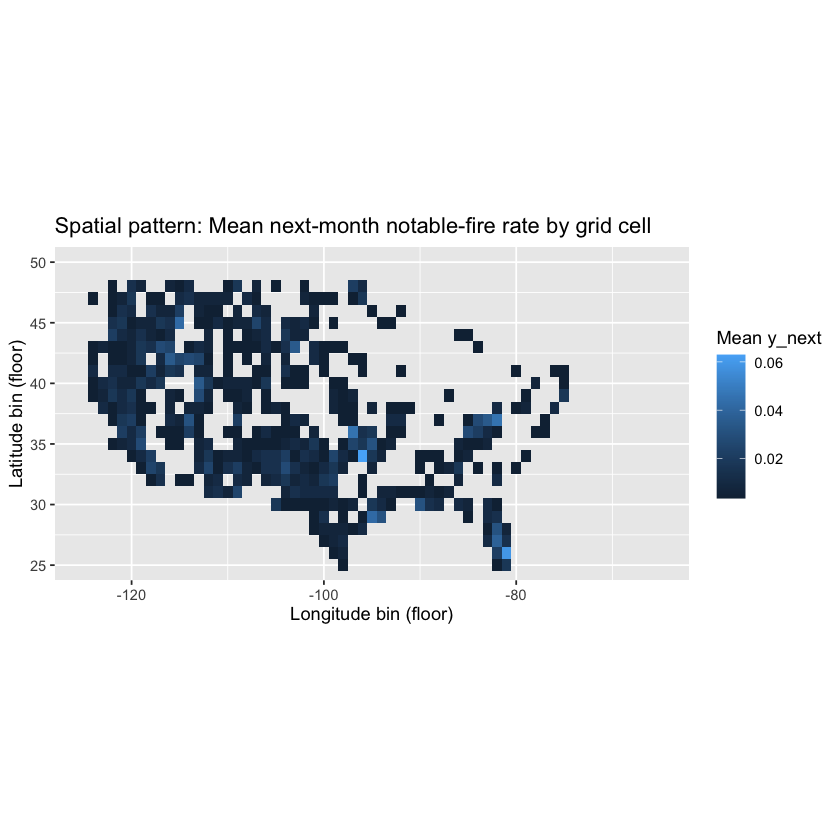

In [12]:
eda_spatial <- panel %>% group_by(lat_bin, lon_bin) %>% summarise(fire_rate = mean(y_next), .group = "drop")


ggplot(eda_spatial, aes(x = lon_bin, y = lat_bin, fill = fire_rate)) +
  coord_quickmap(xlim = c(-125, -65), ylim = c(25, 50)) + 
  geom_tile() +
  labs(
    title = "Spatial pattern: Mean next-month notable-fire rate by grid cell",
    x = "Longitude bin (floor)",
    y = "Latitude bin (floor)",
    fill = "Mean y_next"
  )

Based on the map above, the western United State appears to be more prone to wildfires. This is most likely due to the forests, dry climate, and hot summers, all of which can result in easier fires. The Southwest also appears to be high risk, which may be related to the dry seasons common in the area. In contrast, the Northeast shows a much lower fire risk. which may be explained by the wetter climate, and frequent rain compared to the West and Southwest.

### EDA Plot 2: Temporal pattern

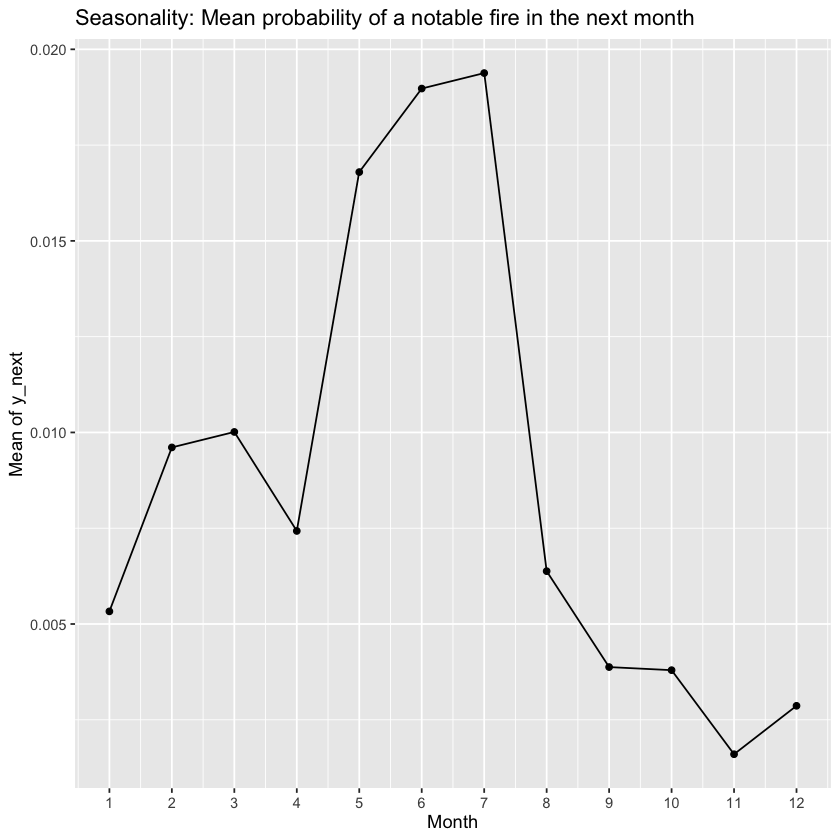

In [13]:
eda_month <- panel %>% group_by(month) %>% summarise(mean_y_next = mean(y_next), .group = "drop")

ggplot(eda_month, aes(x = month, y = mean_y_next)) +
  geom_line() +
  geom_point() +
  scale_x_continuous(breaks = 1:12) +
  labs(
    title = "Seasonality: Mean probability of a notable fire in the next month",
    x = "Month",
    y = "Mean of y_next"
  )

Based on the plot above, there is a clear fire season. There is a heightened fire risk starting in April, with risk peaking in June and July, and returning to normal in August. During the colder months (September to December), there is a decline in fire risk. Another interesting takeaway is the rise in fire risk in February and March, which lines up with the end of the Winter season.

## 3. Modeling
We fit at least **two** models:
1. **Baseline:** Logistic regression (interpretable benchmark)
2. **Model of choice:** Gradient boosted trees (XGBoost)


### Baseline: Logistic Regression

The logistic regression model models fire risk as a weighted combination of predictors (in this case location, month, year, and fire history).

The reason this is the baseline model is due to how simple and interpretable logistic regression is for binary classification problems.

### Model of Choice: XGBoost

The XGBoost model builds decision trees in sequence, while correcting the errors of the previous tree. This repeats multiple times (in this case, 100), and outputs the probability based on the same predictors used in the logistic regression model.

### Model Equation

$$P(y_{g,t} = 1) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 \cdot \text{lat\_bin} + \beta_2 \cdot \text{lon\_bin} + \beta_3 \cdot \text{state} + \beta_4 \cdot \text{month\_cos} + \beta_5 \cdot \text{month\_sin} + \beta_6 \cdot \text{year} + \beta_7 \cdot \text{n\_fires} + \beta_8 \cdot \text{fire\_lag12} + \beta_9 \cdot \text{fire\_roll3} + \beta_{10} \cdot \text{fire\_roll12} + \beta_{11} \cdot \text{size\_roll3} + \beta_{12} \cdot \text{size\_roll12})}}$$


In [14]:
model_df <- panel %>%
  mutate(y_next = factor(y_next, levels = c(0, 1))) %>%
  select(y_next, lat_bin, lon_bin, state, 
         month_cos, month_sin, year, 
         n_fires, fire_lag12, fire_roll3, fire_roll12, size_roll3, size_roll12)
glimpse(model_df)

Rows: 147,576
Columns: 13
$ y_next      <fct> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0…
$ lat_bin     <dbl> 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17…
$ lon_bin     <dbl> -67, -67, -67, -67, -67, -67, -67, -67, -67, -67, -67, -67…
$ state       <fct> PR, PR, PR, PR, PR, PR, PR, PR, PR, PR, PR, PR, PR, PR, PR…
$ month_cos   <dbl> 8.660254e-01, 5.000000e-01, 6.123234e-17, -5.000000e-01, -…
$ month_sin   <dbl> 5.000000e-01, 8.660254e-01, 1.000000e+00, 8.660254e-01, 5.…
$ year        <dbl> 1992, 1992, 1992, 1992, 1992, 1992, 1992, 1992, 1992, 1992…
$ n_fires     <int> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0…
$ fire_lag12  <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0…
$ fire_roll3  <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0…
$ fire_roll12 <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0…
$ size_roll3  <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0…
$ size_roll12 

## 4. Model Fitting and Validation
Validation respects the temporal structure via expanding window. For each fold:
- Train on years $\le t$
- Validate on year $t+1$ with $t\geq 3$

We report **AUC** for both models and include a diagnostic plot for AUC across time folds.


In [16]:
years_sorted <- sort(unique(model_df$year))
min_train_years <- 3

feat_formula <- y_next ~ lat_bin + lon_bin + state + month_cos + month_sin + year +
  n_fires + fire_lag12 + fire_roll3 + fire_roll12 + size_roll3 + size_roll12

fold_results <- tibble(
    train_end_year = years_sorted[(min_train_years):(length(years_sorted) - 2)],
    valid_year = years_sorted[(min_train_years + 1):(length(years_sorted) - 1)]) %>%
  mutate(
      auc_glm = map2_dbl(train_end_year, valid_year, function(tr_end, va_year) {
          train <- model_df %>% filter(year <= tr_end)
          valid <- model_df %>% filter(year == va_year)
          fit <- glm(feat_formula, data = train, family = binomial)
          p_hat <- predict(fit, newdata = valid, type = "response")
          roc_obj <- roc(response = valid$y_next, predictor = p_hat, quiet = TRUE)
          as.numeric(auc(roc_obj))}),
      
      auc_xgb = map2_dbl(train_end_year, valid_year, function(tr_end, va_year) {
          train <- model_df %>% filter(year <= tr_end)
          valid <- model_df %>% filter(year == va_year)
          y_train <- as.numeric(as.character(train$y_next))
          y_valid <- as.numeric(as.character(valid$y_next))
          x_train <- Matrix::sparse.model.matrix(feat_formula, data = train)[, -1]
          x_valid <- Matrix::sparse.model.matrix(feat_formula, data = valid)[, -1]
          dtrain <- xgb.DMatrix(data = x_train, label = y_train)
          dvalid <- xgb.DMatrix(data = x_valid, label = y_valid)
          fit <- xgb.train(
  params = list(
    objective        = "binary:logistic",
    eval_metric      = "auc",
    eta              = 0.05,
    max_depth        = 6,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    min_child_weight = 1
  ),
  data = dtrain,
  nrounds = 100,
  verbose = 0
)
          p_hat <- predict(fit, newdata = dvalid)
          roc_obj <- roc(response = valid$y_next, predictor = p_hat, quiet = TRUE)
          as.numeric(auc(roc_obj))
          })
)
fold_results

[1] 147576

train_end_year,valid_year,auc_glm,auc_xgb
<dbl>,<dbl>,<dbl>,<dbl>
1994,1995,0.6672001,0.7864706
1995,1996,0.7160319,0.8115936
1996,1997,0.8243199,0.8335846
1997,1998,0.7585791,0.8143182
1998,1999,0.6675612,0.7305602
1999,2000,0.7282886,0.7900688
2000,2001,0.7518856,0.8373897
2001,2002,0.7228021,0.8075121
2002,2003,0.7280271,0.8266081


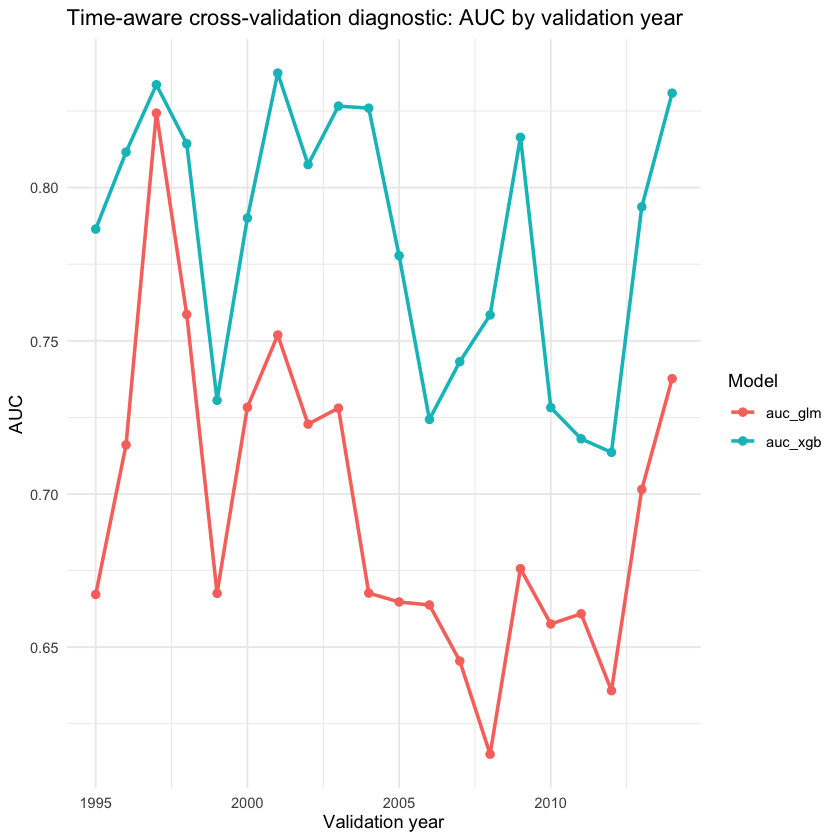

In [17]:
fold_long <- fold_results %>%
  pivot_longer(
    cols = c(auc_glm, auc_xgb),
    names_to = "model",
    values_to = "auc"
  )

ggplot(fold_long, aes(x = valid_year, y = auc, color = model)) +
  geom_line(linewidth = 1) +
  geom_point(size = 2) +
  labs(
    title = "Time-aware cross-validation diagnostic: AUC by validation year",
    x = "Validation year",
    y = "AUC",
    color = "Model"
  ) + 
  theme_minimal()

In [19]:
cat('Overall, XGboost outperforms logistic regression in AUC by ', 
    round(mean(fold_results$auc_xgb) / mean(fold_results$auc_glm) * 100, 2) - 100, "%", sep= '')

Overall, XGboost outperforms logistic regression in AUC by 12.8%

## 5. Summary

### Data Preprocessing and Feature Engineering
- Our dataset begins with 100,000 observations of wildfires, regardless of size.
- We remove all wildfires that span less than 300 acres, so as to keep only notable fires in the dataset.
- We round the longitude and latitude of each wildfire down, to define our grid cells for our grid-by-month panel, and add an indicator variable for whether a fire has occured that month or not.
- We create an empty grid-by-month panel, and combine it with the location and monthly fire occurence data mentioned previously, including non-fire months.
- We then create additional predictors including: state labels, cyclical month encoding, and lagged fire history features to complete our preprocessing.

### Key insights from EDA
- The West Coast, and Southwest were at a higher risk of wildfires compared to the rest of the United States; and the opposite is true for the Northeast, which has very low risk when compared to the West Coast and Southwest.
- There appears to be heightened fire seasons (April- August), which supports the inclusion of cyclical months and long term fire history in the models.

### Modeling takeaway
- Wildfire occurence is better modeled by the XGBoost model, due to the interactions between seasons, locations, and recent fire activity.